# Emotion Detection with DenseNet in PyTorch

**Architecture:** DenseNet121 built from scratch, without pretrained weights.  
**Dataset:** `./dataset` with `train`, `validation`, and `test` folders.

---
## 1. Import Libraries

In [1]:
import json
import os
import random
from collections import defaultdict

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from torch import nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import warnings
warnings.filterwarnings('ignore')

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available:   {torch.cuda.is_available()}')
print(f'MPS available:    {torch.backends.mps.is_available()}')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device:           {DEVICE}')

PyTorch version: 2.12.0
CUDA available:   False
MPS available:    True
Device:           mps


---
## 2. Dataset Configuration & Loading

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────

DATASET_ROOT = '../dataset'
TRAIN_DIR = os.path.join(DATASET_ROOT, 'train')
VALIDATION_DIR = os.path.join(DATASET_ROOT, 'validation')
TEST_DIR = os.path.join(DATASET_ROOT, 'test')

IMG_SIZE = 48
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1e-3
NUM_CLASSES = 8
NUM_WORKERS = 0

EMOTIONS = sorted(os.listdir(TRAIN_DIR))
print(f'Detected {len(EMOTIONS)} emotion classes: {EMOTIONS}')

for split_name, path in [('Train', TRAIN_DIR), ('Validation', VALIDATION_DIR), ('Test', TEST_DIR)]:
    total = sum(len(os.listdir(os.path.join(path, emotion))) for emotion in EMOTIONS)
    print(f'{split_name:12s}: {total:,} images  ({total // len(EMOTIONS)} per class)')

Detected 8 emotion classes: ['Anger', 'Contempt', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']
Train       : 16,000 images  (2000 per class)
Validation  : 3,200 images  (400 per class)
Test        : 3,200 images  (400 per class)


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# DATASETS AND DATALOADERS
# ─────────────────────────────────────────────────────────────────────────────

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(
        degrees=15,
        translate=(0.1, 0.1),
        shear=0.1,
        scale=(0.9, 1.1),
    ),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
validation_dataset = datasets.ImageFolder(VALIDATION_DIR, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=val_test_transforms)

class_to_idx = train_dataset.class_to_idx
idx_to_class = {idx: name for name, idx in class_to_idx.items()}
class_names = [idx_to_class[idx] for idx in range(NUM_CLASSES)]

pin_memory = DEVICE.type == 'cuda'
loader_kwargs = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=pin_memory)
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
    **loader_kwargs,
)
validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    **loader_kwargs,
)
test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_kwargs,
)

print('\nClass → Index mapping:')
for name, idx in class_to_idx.items():
    print(f'  {idx}: {name}')

print(f'\nTrain samples:      {len(train_dataset):,}')
print(f'Validation samples: {len(validation_dataset):,}')
print(f'Test samples:       {len(test_dataset):,}')


Class → Index mapping:
  0: Anger
  1: Contempt
  2: Disgust
  3: Fear
  4: Happiness
  5: Neutral
  6: Sadness
  7: Surprise

Train samples:      16,000
Validation samples: 3,200
Test samples:       3,200


---
## 3. Data Visualization

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# GENERATE PREDICTIONS ON TEST SET
# ─────────────────────────────────────────────────────────────────────────────

required_names = {'checkpoint_path', 'model', 'predict_loader', 'test_loader'}
if required_names.issubset(globals()):
    if os.path.exists(checkpoint_path):
        best_checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
        model.load_state_dict(best_checkpoint['model_state_dict'])
        print(f"Loaded best checkpoint from epoch {best_checkpoint['epoch']}.")

    print('Generating predictions on test set ...')
    y_prob, y_true, y_pred = predict_loader(test_loader)

    print(f'\nTrue labels shape : {y_true.shape}')
    print(f'Pred labels shape : {y_pred.shape}')
else:
    print('Skipping test-set prediction preview until the model and training utilities are defined.')

Skipping test-set prediction preview until the model and training utilities are defined.


---
## 4. Build DenseNet121 from Scratch

**DenseNet (Densely Connected Convolutional Networks)** connects each layer to every other layer in a feed-forward fashion.  
For a layer **ℓ**, it receives feature maps from all preceding layers: $x_\ell = H_\ell([x_0, x_1, ..., x_{\ell-1}])$

This promotes **feature reuse**, reduces **vanishing gradient**, and requires **fewer parameters** than comparable ResNets.

**DenseNet-121 configuration:**
| Block | # Layers |
|-------|----------|
| Dense Block 1 | 6 |
| Dense Block 2 | 12 |
| Dense Block 3 | 24 |
| Dense Block 4 | 16 |

Adapted for **48×48 input** (smaller than ImageNet 224×224 — strides & pooling adjusted accordingly).

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# DENSENET121 BUILT FROM SCRATCH IN PYTORCH
# ─────────────────────────────────────────────────────────────────────────────

class DenseLayer(nn.Module):
    def __init__(self, in_channels, growth_rate):
        super().__init__()
        inter_channels = growth_rate * 4
        self.norm1 = nn.BatchNorm2d(in_channels)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, inter_channels, kernel_size=1, bias=False)
        self.norm2 = nn.BatchNorm2d(inter_channels)
        self.relu2 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(inter_channels, growth_rate, kernel_size=3, padding=1, bias=False)

    def forward(self, x):
        out = self.conv1(self.relu1(self.norm1(x)))
        out = self.conv2(self.relu2(self.norm2(out)))
        return out


class DenseBlock(nn.Module):
    def __init__(self, num_layers, in_channels, growth_rate):
        super().__init__()
        self.layers = nn.ModuleList()
        current_channels = in_channels
        for _ in range(num_layers):
            self.layers.append(DenseLayer(current_channels, growth_rate))
            current_channels += growth_rate

    def forward(self, x):
        for layer in self.layers:
            new_features = layer(x)
            x = torch.cat([x, new_features], dim=1)
        return x


class Transition(nn.Module):
    def __init__(self, in_channels, compression=0.5):
        super().__init__()
        out_channels = max(1, int(in_channels * compression))
        self.norm = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.conv(self.relu(self.norm(x)))
        return self.pool(x)


class DenseNet121Scratch(nn.Module):
    def __init__(
        self,
        input_channels=3,
        num_classes=8,
        growth_rate=32,
        compression=0.5,
        block_layers=(6, 12, 24, 16),
        dropout_rate=0.3,
    ):
        super().__init__()
        self.stem_conv = nn.Conv2d(input_channels, 2 * growth_rate, kernel_size=3, stride=1, padding=1, bias=False)
        self.stem_bn = nn.BatchNorm2d(2 * growth_rate)
        self.stem_relu = nn.ReLU(inplace=True)

        self.blocks = nn.ModuleList()
        self.transitions = nn.ModuleList()
        num_features = 2 * growth_rate

        for block_idx, num_layers in enumerate(block_layers):
            block = DenseBlock(num_layers, num_features, growth_rate)
            self.blocks.append(block)
            num_features += num_layers * growth_rate

            if block_idx < len(block_layers) - 1:
                self.transitions.append(Transition(num_features, compression=compression))
                num_features = max(1, int(num_features * compression))

        self.final_bn = nn.BatchNorm2d(num_features)
        self.final_relu = nn.ReLU(inplace=True)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(num_features, num_classes)

        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, nn.Conv2d):
            nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
        elif isinstance(module, nn.BatchNorm2d):
            nn.init.constant_(module.weight, 1.0)
            nn.init.constant_(module.bias, 0.0)
        elif isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, 0.0, 0.01)
            nn.init.constant_(module.bias, 0.0)

    def forward(self, x):
        x = self.stem_relu(self.stem_bn(self.stem_conv(x)))

        for block_idx, block in enumerate(self.blocks):
            x = block(x)
            if block_idx < len(self.transitions):
                x = self.transitions[block_idx](x)

        x = self.final_relu(self.final_bn(x))
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.classifier(x)


def build_densenet121(
    input_channels=3,
    num_classes=8,
    growth_rate=32,
    compression=0.5,
    block_layers=(6, 12, 24, 16),
    dropout_rate=0.3,
):
    return DenseNet121Scratch(
        input_channels=input_channels,
        num_classes=num_classes,
        growth_rate=growth_rate,
        compression=compression,
        block_layers=block_layers,
        dropout_rate=dropout_rate,
    )


model = build_densenet121(
    input_channels=3,
    num_classes=NUM_CLASSES,
    growth_rate=32,
    compression=0.5,
    block_layers=(6, 12, 24, 16),
    dropout_rate=0.3,
).to(DEVICE)

num_parameters = sum(parameter.numel() for parameter in model.parameters())
print(model)
print(f'\nTrainable parameters: {num_parameters:,}')

DenseNet121Scratch(
  (stem_conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (stem_relu): ReLU(inplace=True)
  (blocks): ModuleList(
    (0): DenseBlock(
      (layers): ModuleList(
        (0): DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (1): DenseLayer(
          (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (relu1): ReLU(inplac

---
## 5. Compile & Train the Model

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# OPTIMISATION, SCHEDULING, AND HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
checkpoint_path = 'best_densenet_emotion.pt'


def run_epoch(loader, training=True):
    if training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=pin_memory)
        labels = labels.to(DEVICE, non_blocking=pin_memory)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            outputs = model(images)
            loss = criterion(outputs, labels)
            if training:
                loss.backward()
                optimizer.step()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        predictions = outputs.argmax(dim=1)
        running_correct += (predictions == labels).sum().item()
        running_total += batch_size

    avg_loss = running_loss / running_total
    avg_acc = running_correct / running_total
    return avg_loss, avg_acc


def predict_loader(loader):
    model.eval()
    all_probs = []
    all_true = []
    all_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=pin_memory)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = probs.argmax(dim=1)

            all_probs.append(probs.cpu().numpy())
            all_true.append(labels.numpy())
            all_pred.append(preds.cpu().numpy())

    y_prob = np.concatenate(all_probs, axis=0)
    y_true = np.concatenate(all_true, axis=0)
    y_pred = np.concatenate(all_pred, axis=0)
    return y_prob, y_true, y_pred


print('Training utilities ready.')

Training utilities ready.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAIN
# ─────────────────────────────────────────────────────────────────────────────

history = defaultdict(list)
best_val_acc = 0.0
best_val_loss = float('inf')
best_val_acc_epoch = 0
best_val_loss_epoch = 0
patience = 10
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, training=True)
    val_loss, val_acc = run_epoch(validation_loader, training=False)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_acc_epoch = epoch
        epochs_without_improvement = 0
        torch.save(
            {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_acc': best_val_acc,
                'class_to_idx': class_to_idx,
                'img_size': IMG_SIZE,
                'num_classes': NUM_CLASSES,
            },
            checkpoint_path,
        )
    else:
        epochs_without_improvement += 1

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_loss_epoch = epoch

    print(
        f'Epoch {epoch:02d}/{EPOCHS:02d} | '
        f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
        f'val_loss={val_loss:.4f} val_acc={val_acc:.4f} | '
        f'lr={optimizer.param_groups[0]["lr"]:.2e}'
    )

    if epochs_without_improvement >= patience:
        print(f'Early stopping triggered after {epoch} epochs.')
        break

if os.path.exists(checkpoint_path):
    best_checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(best_checkpoint['model_state_dict'])
    print(f'\nLoaded best model from epoch {best_checkpoint["epoch"]} with val accuracy {best_checkpoint["best_val_acc"]:.4f}.')

print('\n✅ Training complete!')

Epoch 01/50 | train_loss=0.9696 train_acc=0.6419 | val_loss=1.0692 val_acc=0.6328 | lr=1.00e-03
Epoch 02/50 | train_loss=0.3174 train_acc=0.8897 | val_loss=1.3606 val_acc=0.6631 | lr=1.00e-03
Epoch 03/50 | train_loss=0.1770 train_acc=0.9408 | val_loss=1.4047 val_acc=0.6191 | lr=1.00e-03
Epoch 04/50 | train_loss=0.1144 train_acc=0.9609 | val_loss=1.8804 val_acc=0.5822 | lr=1.00e-03
Epoch 05/50 | train_loss=0.0977 train_acc=0.9668 | val_loss=1.3711 val_acc=0.7331 | lr=1.00e-03
Epoch 06/50 | train_loss=0.0871 train_acc=0.9729 | val_loss=0.8299 val_acc=0.7650 | lr=1.00e-03
Epoch 07/50 | train_loss=0.0746 train_acc=0.9751 | val_loss=0.7687 val_acc=0.7700 | lr=1.00e-03
Epoch 08/50 | train_loss=0.0498 train_acc=0.9837 | val_loss=1.8675 val_acc=0.6503 | lr=1.00e-03
Epoch 09/50 | train_loss=0.0619 train_acc=0.9789 | val_loss=1.2357 val_acc=0.7356 | lr=1.00e-03
Epoch 10/50 | train_loss=0.0542 train_acc=0.9811 | val_loss=1.7362 val_acc=0.6797 | lr=1.00e-03
Epoch 11/50 | train_loss=0.0482 train_ac

---
## 6. Training vs Validation — Accuracy & Loss Curves

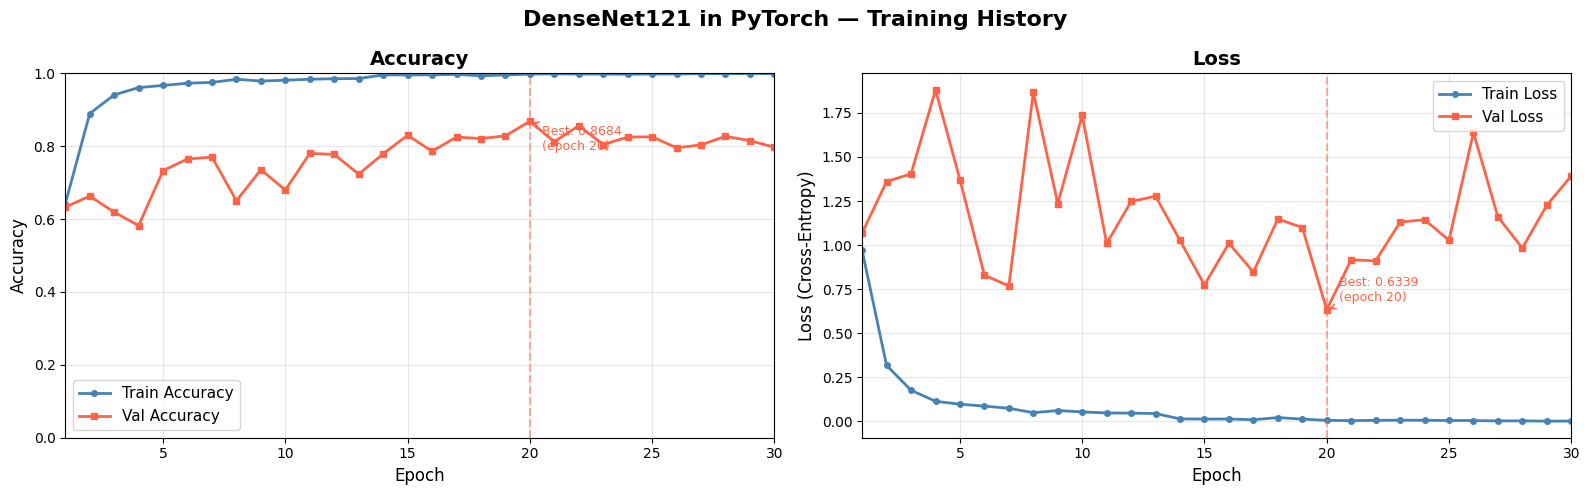

Plot saved as training_curves.png


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAINING vs VALIDATION — ACCURACY & LOSS CURVES
# ─────────────────────────────────────────────────────────────────────────────

epochs_ran = range(1, len(history['train_acc']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('DenseNet121 in PyTorch — Training History', fontsize=16, fontweight='bold')

ax = axes[0]
ax.plot(epochs_ran, history['train_acc'], color='steelblue', linewidth=2, marker='o', markersize=4, label='Train Accuracy')
ax.plot(epochs_ran, history['val_acc'], color='tomato', linewidth=2, marker='s', markersize=4, label='Val Accuracy')
ax.set_title('Accuracy', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, len(epochs_ran))
ax.set_ylim(0, 1)
ax.axvline(x=best_val_acc_epoch, color='tomato', linestyle='--', alpha=0.5)
ax.annotate(
    f'Best: {best_val_acc:.4f}\n(epoch {best_val_acc_epoch})',
    xy=(best_val_acc_epoch, best_val_acc),
    xytext=(best_val_acc_epoch + 0.5, max(0.05, best_val_acc - 0.08)),
    fontsize=9,
    color='tomato',
    arrowprops=dict(arrowstyle='->', color='tomato'),
)

ax = axes[1]
ax.plot(epochs_ran, history['train_loss'], color='steelblue', linewidth=2, marker='o', markersize=4, label='Train Loss')
ax.plot(epochs_ran, history['val_loss'], color='tomato', linewidth=2, marker='s', markersize=4, label='Val Loss')
ax.set_title('Loss', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (Cross-Entropy)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, len(epochs_ran))
ax.axvline(x=best_val_loss_epoch, color='tomato', linestyle='--', alpha=0.5)
ax.annotate(
    f'Best: {best_val_loss:.4f}\n(epoch {best_val_loss_epoch})',
    xy=(best_val_loss_epoch, best_val_loss),
    xytext=(best_val_loss_epoch + 0.5, best_val_loss + 0.05),
    fontsize=9,
    color='tomato',
    arrowprops=dict(arrowstyle='->', color='tomato'),
)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as training_curves.png')

---
## 7. Performance Metrics

Evaluate on the **held-out test set** (never seen during training or validation).

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# GENERATE PREDICTIONS ON TEST SET
# ─────────────────────────────────────────────────────────────────────────────

if 'predict_loader' not in globals():
    raise RuntimeError('Run the training utilities cell before this evaluation cell.')

if os.path.exists(checkpoint_path):
    best_checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(best_checkpoint['model_state_dict'])
    print(f"Loaded best checkpoint from epoch {best_checkpoint['epoch']}.")

print('Generating predictions on test set ...')
y_prob, y_true, y_pred = predict_loader(test_loader)

# Map indices back to class names
class_names = [idx_to_class[i] for i in range(NUM_CLASSES)]

print(f'\nTrue labels shape : {y_true.shape}')
print(f'Pred labels shape : {y_pred.shape}')

Loaded best checkpoint from epoch 20.
Generating predictions on test set ...

True labels shape : (3200,)
Pred labels shape : (3200,)


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# OVERALL METRICS
# ─────────────────────────────────────────────────────────────────────────────

acc = accuracy_score(y_true, y_pred)
prec_w = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec_w = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1_w = f1_score(y_true, y_pred, average='weighted', zero_division=0)
prec_m = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec_m = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1_m = f1_score(y_true, y_pred, average='macro', zero_division=0)

print('=' * 60)
print('           OVERALL PERFORMANCE METRICS (Test Set)')
print('=' * 60)
print(f'  Accuracy                        : {acc:.4f}  ({acc * 100:.2f}%)')
print()
print(f'  Weighted Precision               : {prec_w:.4f}')
print(f'  Weighted Recall                  : {rec_w:.4f}')
print(f'  Weighted F1-Score                : {f1_w:.4f}')
print()
print(f'  Macro Precision                  : {prec_m:.4f}')
print(f'  Macro Recall                     : {rec_m:.4f}')
print(f'  Macro F1-Score                   : {f1_m:.4f}')
print('=' * 60)

           OVERALL PERFORMANCE METRICS (Test Set)
  Accuracy                        : 0.8888  (88.88%)

  Weighted Precision               : 0.9060
  Weighted Recall                  : 0.8888
  Weighted F1-Score                : 0.8733

  Macro Precision                  : 0.9060
  Macro Recall                     : 0.8888
  Macro F1-Score                   : 0.8733


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# PER-CLASS CLASSIFICATION REPORT
# ─────────────────────────────────────────────────────────────────────────────

print('\nDetailed Classification Report:')
print('-' * 60)
report_str = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report_str)

report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)


Detailed Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

       Anger     0.7000    0.9100    0.7913       400
    Contempt     0.9091    1.0000    0.9524       400
     Disgust     0.9875    0.9875    0.9875       400
        Fear     1.0000    0.9475    0.9730       400
   Happiness     0.9406    0.9900    0.9647       400
     Neutral     0.7564    0.9625    0.8471       400
     Sadness     0.9542    0.3125    0.4708       400
    Surprise     1.0000    1.0000    1.0000       400

    accuracy                         0.8888      3200
   macro avg     0.9060    0.8888    0.8733      3200
weighted avg     0.9060    0.8888    0.8733      3200



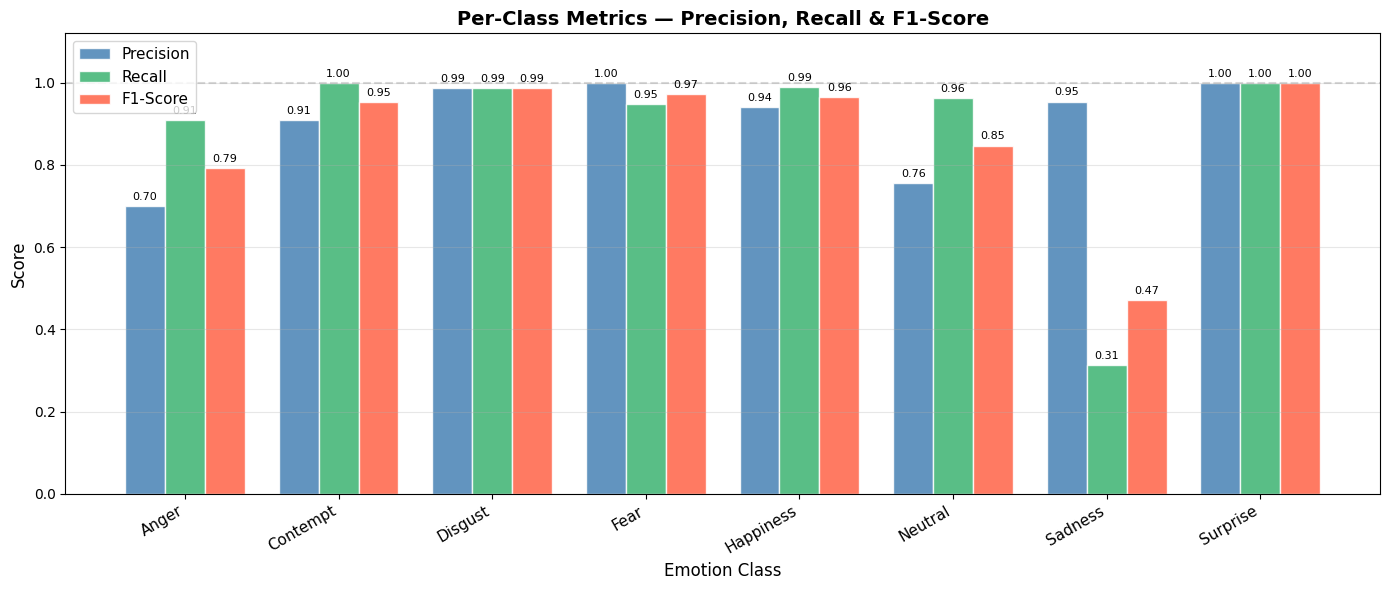

Plot saved as per_class_metrics.png


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# PER-CLASS METRICS — BAR CHART
# ─────────────────────────────────────────────────────────────────────────────

per_class_precision = [report_dict[c]['precision'] for c in class_names]
per_class_recall = [report_dict[c]['recall'] for c in class_names]
per_class_f1 = [report_dict[c]['f1-score'] for c in class_names]

x = np.arange(len(class_names))
width = 0.26

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width, per_class_precision, width, label='Precision', color='steelblue', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x, per_class_recall, width, label='Recall', color='mediumseagreen', alpha=0.85, edgecolor='white')
bars3 = ax.bar(x + width, per_class_f1, width, label='F1-Score', color='tomato', alpha=0.85, edgecolor='white')

ax.set_title('Per-Class Metrics — Precision, Recall & F1-Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Emotion Class', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha='right', fontsize=11)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as per_class_metrics.png')

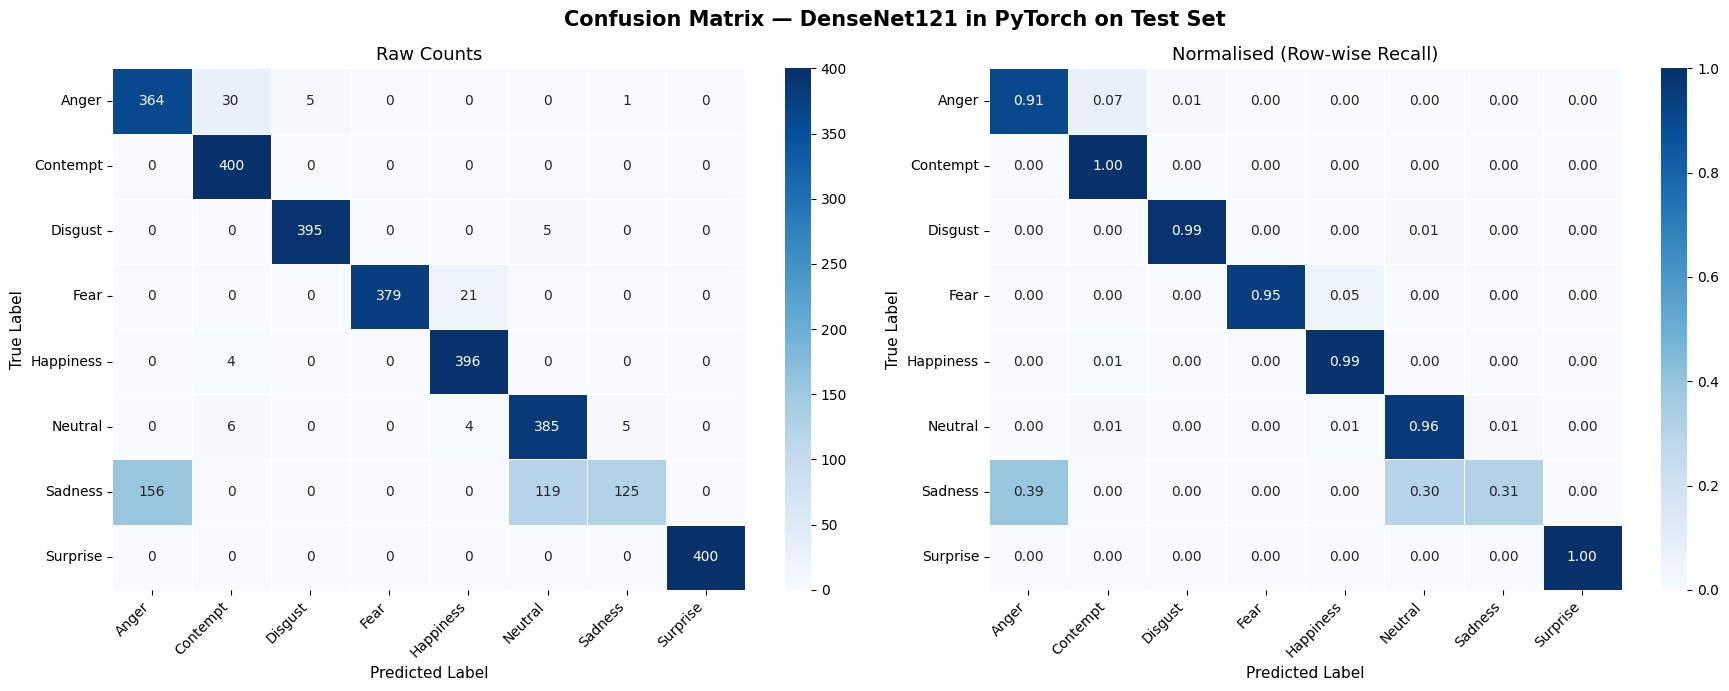

Plot saved as confusion_matrix.png


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFUSION MATRIX
# ─────────────────────────────────────────────────────────────────────────────

cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Confusion Matrix — DenseNet121 in PyTorch on Test Set', fontsize=15, fontweight='bold')

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    ax=axes[0],
)
axes[0].set_title('Raw Counts', fontsize=13)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0].set_yticklabels(class_names, rotation=0)

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    vmin=0,
    vmax=1,
    ax=axes[1],
)
axes[1].set_title('Normalised (Row-wise Recall)', fontsize=13)
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].set_yticklabels(class_names, rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as confusion_matrix.png')

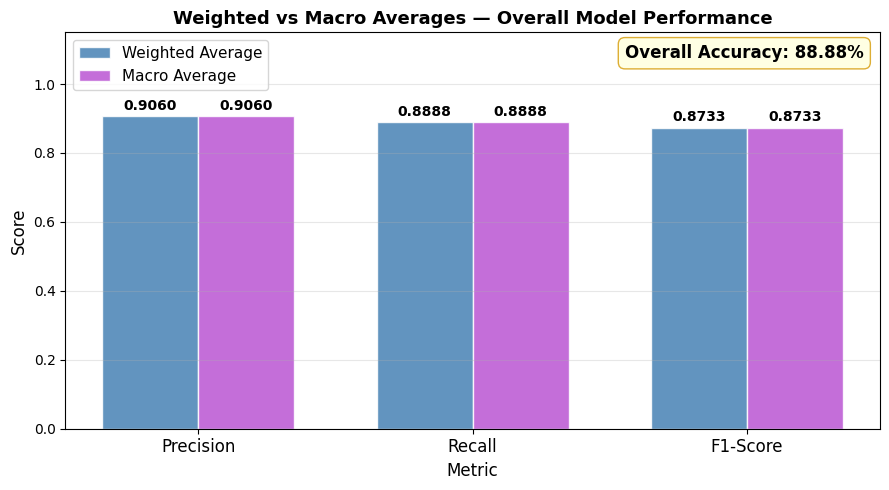

Plot saved as summary_metrics.png


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY DASHBOARD — Weighted vs Macro comparison
# ─────────────────────────────────────────────────────────────────────────────

metrics_labels = ['Precision', 'Recall', 'F1-Score']
weighted_scores = [prec_w, rec_w, f1_w]
macro_scores = [prec_m, rec_m, f1_m]

x2 = np.arange(len(metrics_labels))
width2 = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x2 - width2 / 2, weighted_scores, width2, label='Weighted Average', color='steelblue', alpha=0.85, edgecolor='white')
b2 = ax.bar(x2 + width2 / 2, macro_scores, width2, label='Macro Average', color='mediumorchid', alpha=0.85, edgecolor='white')

ax.set_title('Weighted vs Macro Averages — Overall Model Performance', fontsize=13, fontweight='bold')
ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_xticks(x2)
ax.set_xticklabels(metrics_labels, fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in list(b1) + list(b2):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.annotate(
    f'Overall Accuracy: {acc * 100:.2f}%',
    xy=(0.98, 0.97),
    xycoords='axes fraction',
    ha='right',
    va='top',
    fontsize=12,
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', ec='goldenrod', alpha=0.9),
)

plt.tight_layout()
plt.savefig('summary_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as summary_metrics.png')

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# FINAL CONSOLIDATED SUMMARY TABLE
# ─────────────────────────────────────────────────────────────────────────────

print('\n' + '=' * 72)
print('                  FINAL PERFORMANCE SUMMARY — TEST SET')
print('=' * 72)
print(f"{'Metric':<40} {'Score':>10}")
print('-' * 52)
print(f"{'Accuracy':<40} {acc:>10.4f}")
print()
print(f"{'Weighted Avg Precision':<40} {prec_w:>10.4f}")
print(f"{'Weighted Avg Recall':<40} {rec_w:>10.4f}")
print(f"{'Weighted Avg F1-Score':<40} {f1_w:>10.4f}")
print()
print(f"{'Macro Avg Precision':<40} {prec_m:>10.4f}")
print(f"{'Macro Avg Recall':<40} {rec_m:>10.4f}")
print(f"{'Macro Avg F1-Score':<40} {f1_m:>10.4f}")
print('-' * 52)
print()
print('Per-Class F1-Scores:')
for cls, f1_value in zip(class_names, per_class_f1):
    bar = '█' * int(f1_value * 30)
    print(f'  {cls:<12} {f1_value:.4f}  {bar}')
print('=' * 72)
best_val_acc_text = f'{best_val_acc:.4f} (Epoch {best_val_acc_epoch})' if 'best_val_acc' in globals() else 'N/A (run training first)'
best_val_loss_text = f'{best_val_loss:.4f} (Epoch {best_val_loss_epoch})' if 'best_val_loss' in globals() else 'N/A (run training first)'
print(f'  Best Validation Accuracy : {best_val_acc_text}')
print(f'  Best Validation Loss     : {best_val_loss_text}')
print('=' * 72)


                  FINAL PERFORMANCE SUMMARY — TEST SET
Metric                                        Score
----------------------------------------------------
Accuracy                                     0.8888

Weighted Avg Precision                       0.9060
Weighted Avg Recall                          0.8888
Weighted Avg F1-Score                        0.8733

Macro Avg Precision                          0.9060
Macro Avg Recall                             0.8888
Macro Avg F1-Score                           0.8733
----------------------------------------------------

Per-Class F1-Scores:
  Anger        0.7913  ███████████████████████
  Contempt     0.9524  ████████████████████████████
  Disgust      0.9875  █████████████████████████████
  Fear         0.9730  █████████████████████████████
  Happiness    0.9647  ████████████████████████████
  Neutral      0.8471  █████████████████████████
  Sadness      0.4708  ██████████████
  Surprise     1.0000  ██████████████████████████████


---
## 8. Save the Model

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# SAVE FINAL MODEL
# ─────────────────────────────────────────────────────────────────────────────

full_model_path = 'densenet121_emotion_final.pt'
weights_path = 'densenet121_emotion_weights.pt'

checkpoint = {
    'model_state_dict': model.state_dict(),
    'class_to_idx': class_to_idx,
    'img_size': IMG_SIZE,
    'num_classes': NUM_CLASSES,
    'growth_rate': 32,
    'compression': 0.5,
    'block_layers': (6, 12, 24, 16),
    'dropout_rate': 0.3,
}
torch.save(checkpoint, full_model_path)
print(f'✅ Full model saved  →  {full_model_path}')

torch.save(model.state_dict(), weights_path)
print(f'✅ Weights saved     →  {weights_path}')

with open('class_indices.json', 'w') as f:
    json.dump(class_to_idx, f, indent=2)
print('✅ Class indices saved→  class_indices.json')

print('\n📦 Files generated in this session:')
for fname in [full_model_path, weights_path, checkpoint_path, 'class_indices.json', 'training_curves.png', 'per_class_metrics.png', 'confusion_matrix.png', 'summary_metrics.png']:
    exists = '✓' if os.path.exists(fname) else '✗'
    print(f'  [{exists}] {fname}')

✅ Full model saved  →  densenet121_emotion_final.pt
✅ Weights saved     →  densenet121_emotion_weights.pt
✅ Class indices saved→  class_indices.json

📦 Files generated in this session:
  [✓] densenet121_emotion_final.pt
  [✓] densenet121_emotion_weights.pt
  [✓] best_densenet_emotion.pt
  [✓] class_indices.json
  [✓] training_curves.png
  [✓] per_class_metrics.png
  [✓] confusion_matrix.png
  [✓] summary_metrics.png


---
## Bonus: Quick Inference on a Single Image

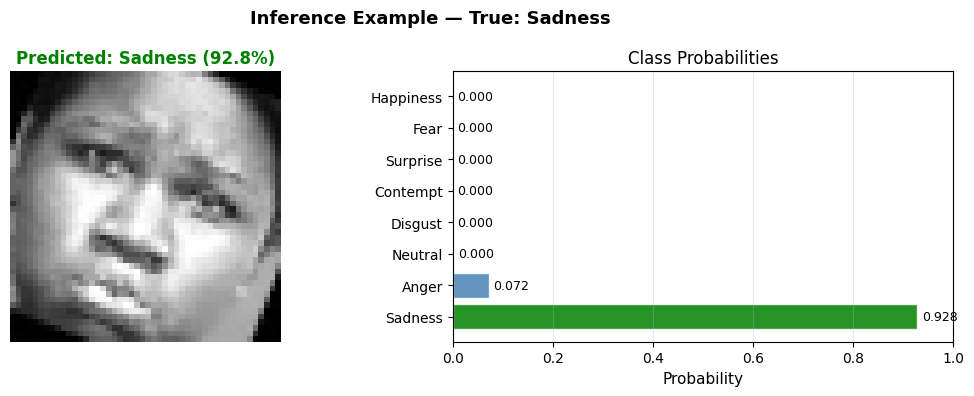

True label : Sadness
Predicted  : Sadness (confidence: 92.79%)
Result     : ✅ CORRECT


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# QUICK INFERENCE — predict emotion for one image
# ─────────────────────────────────────────────────────────────────────────────

def predict_emotion(img_path, model, idx_to_class, img_size=48, device=DEVICE):
    """Load an image, preprocess it, and return the predicted emotion."""
    image = Image.open(img_path).convert('RGB')
    image_tensor = val_test_transforms(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        probabilities = torch.softmax(model(image_tensor), dim=1)[0].cpu().numpy()

    pred_idx = int(np.argmax(probabilities))
    predicted_class = idx_to_class[pred_idx]
    confidence = float(probabilities[pred_idx])
    all_probs = {idx_to_class[i]: float(probabilities[i]) for i in range(len(probabilities))}
    return predicted_class, confidence, all_probs


sample_path, sample_label_idx = random.choice(test_dataset.samples)
sample_emotion = idx_to_class[sample_label_idx]
pred_class, confidence, all_probs = predict_emotion(sample_path, model, idx_to_class)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle(f'Inference Example — True: {sample_emotion}', fontsize=13, fontweight='bold')

img_display = Image.open(sample_path).convert('RGB')
axes[0].imshow(img_display)
color = 'green' if pred_class == sample_emotion else 'red'
axes[0].set_title(f'Predicted: {pred_class} ({confidence * 100:.1f}%)', color=color, fontsize=12, fontweight='bold')
axes[0].axis('off')

sorted_probs = dict(sorted(all_probs.items(), key=lambda item: item[1], reverse=True))
bar_colors = ['green' if class_name == sample_emotion else ('steelblue' if class_name != pred_class else 'tomato') for class_name in sorted_probs.keys()]
axes[1].barh(list(sorted_probs.keys()), list(sorted_probs.values()), color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('Probability', fontsize=11)
axes[1].set_title('Class Probabilities', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)
for i, (class_name, probability) in enumerate(sorted_probs.items()):
    axes[1].text(probability + 0.01, i, f'{probability:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()
print(f'True label : {sample_emotion}')
print(f'Predicted  : {pred_class} (confidence: {confidence * 100:.2f}%)')
correct = '✅ CORRECT' if pred_class == sample_emotion else '❌ INCORRECT'
print(f'Result     : {correct}')